In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("DMR40@100DegC.csv")
print(df)

            KHz          mT       mw/cm3
0     25.000000   50.514228     1.418727
1     25.000000   52.829287     1.628234
2     25.000000   56.683866     1.998024
3     25.000000   62.175152     2.597154
4     25.000000   69.469779     3.542867
..          ...         ...          ...
207  348.416447  200.000000  3693.397252
208  373.625902  200.000000  4292.069471
209  399.335409  200.000000  4984.821127
210  425.237479  200.000000  5783.647724
211  450.970856  200.000000  6701.172640

[212 rows x 3 columns]


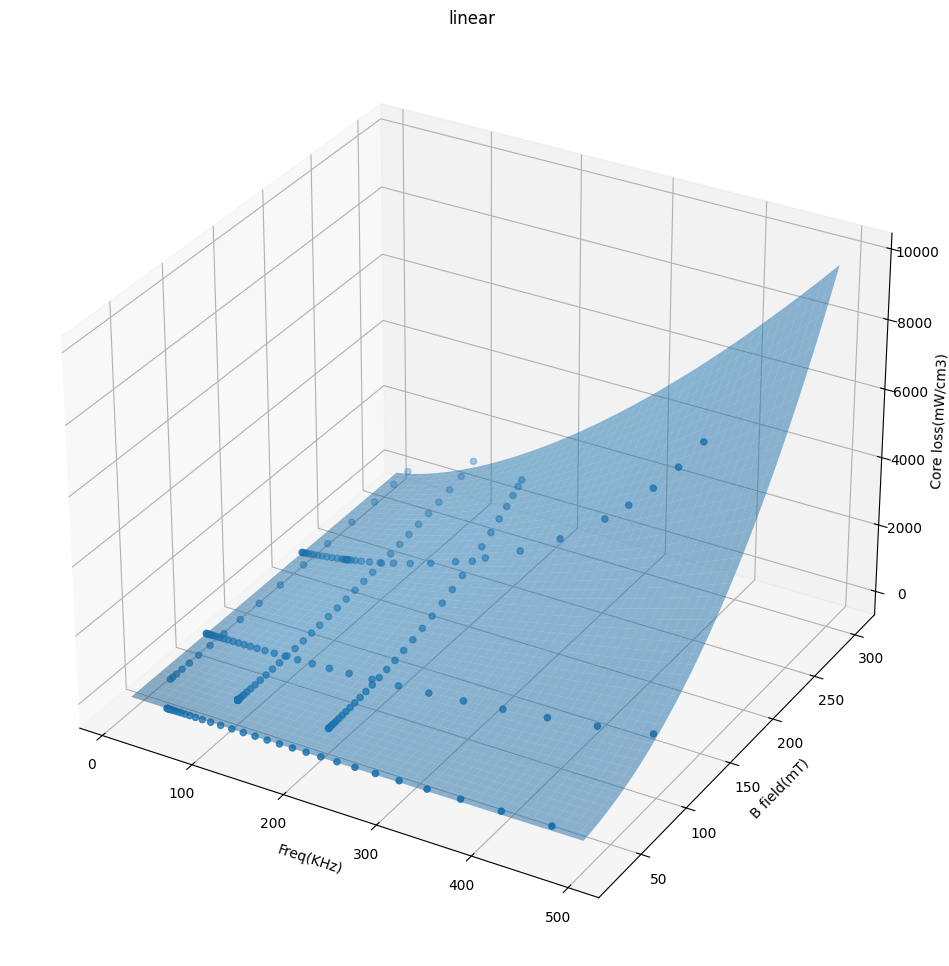

In [54]:
data = df.to_numpy()

F = data[:,0]
B = data[:,1]
P = data[:,2]

fig = plt.figure(figsize=(12,12))
X = np.arange(min(F), max(F), 0.25)
Y = np.arange(min(B), max(B), 0.25)
X, Y = np.meshgrid(X, Y)
ax1 = fig.add_subplot(111, projection='3d')
Z = np.power(10,-5.45942) * np.power(X,1.503341) * np.power(Y,2.172897)

# draw
points = ax1.scatter(F, B, P)
surf = ax1.plot_surface(X, Y, Z, alpha=0.5)


# set axis label
ax1.set_xlabel('Freq(KHz)')
ax1.set_ylabel('B field(mT)')
ax1.set_zlabel('Core loss(mW/cm3)')
ax1.set(title='linear')
ax1.grid()
ax1.grid(which="minor", color="0.9")


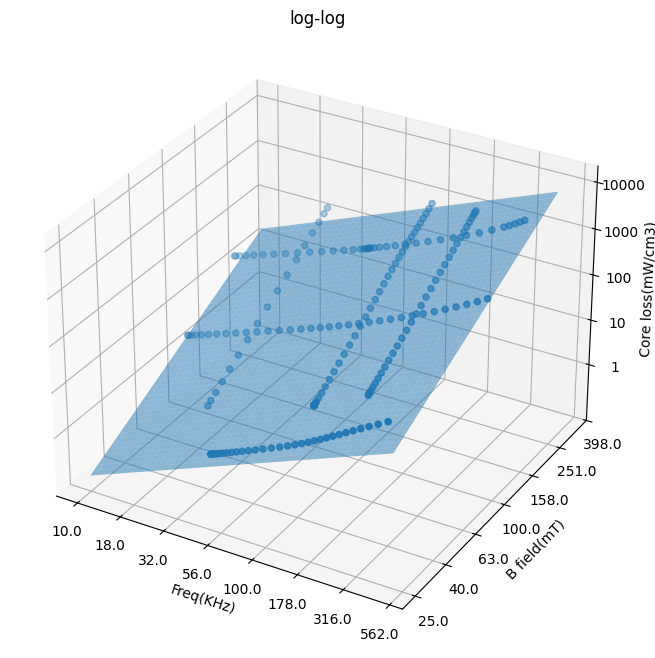

In [53]:
fig = plt.figure(figsize=(8,8))

ax1 = fig.add_subplot(111, projection='3d')
# draw
X = np.arange(min(np.log10(F)), max(np.log10(F)), 0.0025)
Y = np.arange(min(np.log10(B)), max(np.log10(B)), 0.0025)
X, Y = np.meshgrid(X, Y)
Z = -5.45942+X*1.503341+Y*2.172897

points = ax1.scatter(np.log10(F), np.log10(B), np.log10(P))
surf = ax1.plot_surface(X, Y, Z, alpha=0.5)


# set axis label
ax1.set_xlabel('Freq(KHz)')
ax1.set_ylabel('B field(mT)')
ax1.set_zlabel('Core loss(mW/cm3)')
ax1.set(title='log-log')


ax1.set_xticks(list(np.arange(1,3,0.25)))
ax1.set_xticklabels([np.round(np.power(10,i)) for i in np.arange(1,3,0.25)])
ax1.set_yticks(list(np.arange(1.4,2.6,0.2)))
ax1.set_yticklabels([np.round(np.power(10,i)) for i in np.arange(1.4,2.6,0.2)])
ax1.set_zticks(list(np.arange(0,5,1)))
ax1.set_zticklabels([np.round(np.power(10,i)) for i in np.arange(0,5,1)])

ax1.grid()
ax1.grid(which="minor", color="0.9")